# Converting to gwfast format

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os

In [2]:
folder = './injection_sampler_v3_z_0.5_10_years'
f = h5py.File(os.path.join(folder, 'pop_m_FP4_spin_NS_fref_5.0_z_MD_lmr_130_BNS_29K_samples_v3_z_0.5_10_years.h5'), 'r')
f.keys()

<KeysViewHDF5 ['chi_1', 'chi_1_in_plane', 'chi_2', 'chi_2_in_plane', 'chi_eff', 'chi_p', 'chirp_mass', 'chirp_mass_source', 'config', 'dec', 'geocent_time', 'lambda_1', 'lambda_2', 'luminosity_distance', 'mass_1', 'mass_1_source', 'mass_2', 'mass_2_source', 'mass_ratio', 'phase', 'psi', 'ra', 'redshift', 'reference_frequency', 'spin_1x', 'spin_1y', 'spin_1z', 'spin_2x', 'spin_2y', 'spin_2z', 'symmetric_mass_ratio', 'theta_jn', 'total_mass', 'total_mass_source']>

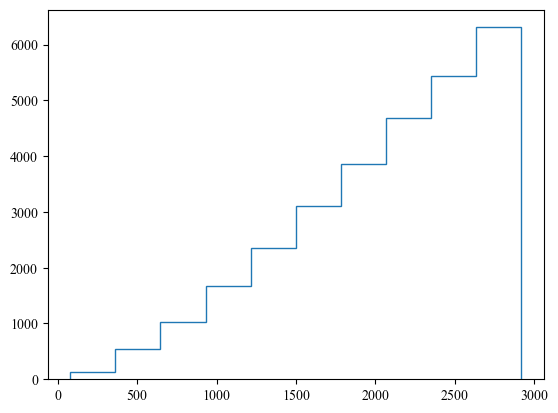

In [3]:
plt.hist(f['luminosity_distance'][:],histtype='step');

In [4]:
pop_dict_gwfast = {}

pop_dict_gwfast['m1_src'] = f['mass_1_source'][:]
pop_dict_gwfast['m2_src'] = f['mass_2_source'][:]
pop_dict_gwfast['z'] = f['redshift'][:]
pop_dict_gwfast['dL'] = f['luminosity_distance'][:]/1000
pop_dict_gwfast['chi1z'] = f['spin_1z'][:]
pop_dict_gwfast['chi2z'] = f['spin_2z'][:]
pop_dict_gwfast['psi'] = f['psi'][:]
pop_dict_gwfast['thetaJN'] = f['theta_jn'][:]
pop_dict_gwfast['theta'] = np.pi/2. - f['dec'][:]
pop_dict_gwfast['phi'] = f['ra'][:]
pop_dict_gwfast['ra'] = f['ra'][:]
pop_dict_gwfast['dec'] = f['dec'][:]

seed = 42
Nevents = len(f['mass_1_source'][:])
rng_phicoal = np.random.default_rng(seed+6)
rng_tcoal = np.random.default_rng(seed+7)
pop_dict_gwfast['Phicoal'] = rng_phicoal.uniform(0, 2*np.pi, Nevents)
pop_dict_gwfast['tcoal'] = rng_tcoal.uniform(0, 1, Nevents)
pop_dict_gwfast['Mc'] = f['chirp_mass'][:]
pop_dict_gwfast['eta'] = f['symmetric_mass_ratio'][:]

pop_dict_gwfast['Lambda1'] = f['lambda_1'][:]
pop_dict_gwfast['Lambda2'] = f['lambda_2'][:]

In [8]:
pop_dict_gwfast.keys()

dict_keys(['m1_src', 'm2_src', 'z', 'dL', 'chi1z', 'chi2z', 'psi', 'thetaJN', 'theta', 'phi', 'ra', 'dec', 'Phicoal', 'tcoal', 'Mc', 'eta', 'Lambda1', 'Lambda2'])

In [9]:
len(pop_dict_gwfast.keys())

18

In [11]:
# Saving samples in a h5 file
import h5py
outfolder = 'pop_gwfast_format'
if not os.path.exists(outfolder):
    os.makedirs(outfolder)
fname = os.path.join(outfolder, 'BNS_cat_10yr.h5')
with h5py.File(fname, 'w') as out:
                
    def cd(n, d):
        d = np.array(d)
        out.create_dataset(n, data=d, compression='gzip', shuffle=True)
    
    for key in pop_dict_gwfast.keys():
        cd(key, pop_dict_gwfast[key])